# Features Pair Analysis: Correlation Matrix + Price Boxplots

Workflow:
1. Data loading and basic preprocessing.
2. Feature-pair analysis using correlation methods.
3. Boxplot-based relationship analysis between selected features and `Price_Adjusted_VAT`.


# 1) Raw Data Loading


In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


In [65]:

csv_path = '../model_training/train_data_clean.csv'

df = pd.read_csv(csv_path)

print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape}')
display(df.head(3))


Loaded: ../model_training/train_data_clean.csv
Shape: (53991, 9)


,Date of Sale (dd/mm/yyyy),Sale Year,Sale Month,is_apartment,location,Description of Property,Not Full Market Price,Price_Adjusted_VAT_Clamped,vat_adjusted_flag
0,2016-09-30,2016,9,0,Cork,Second-Hand Dwelling house /Apartment,No,181000.00000,0
1,2016-12-20,2016,12,0,Cork,New Dwelling house /Apartment,No,60000.00000,1
2,2016-09-28,2016,9,1,Wexford,New Dwelling house /Apartment,No,70565.00435,1


In [67]:
# Cell purpose: clean the price field, split date fields, and build the analysis dataset.
csv_path = '../model_training/train_data_clean.csv'
df = pd.read_csv(csv_path)

price_col = 'Price_Adjusted_VAT_Clamped'
if price_col not in df.columns:
    raise KeyError(f"Column '{price_col}' not found in dataframe. Available: {df.columns.tolist()}")

df[price_col] = pd.to_numeric(
    df[price_col].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

for c in df.columns:
    if 'date' in c.lower():
        dt = pd.to_datetime(df[c], dayfirst=True, errors='coerce')
        if dt.notna().sum() > 0:
            base = c.replace(' (dd/mm/yyyy)', '').replace(' ', '_')
            df[f'{base}_Year'] = dt.dt.year.astype('Int64')
            df[f'{base}_Month'] = dt.dt.month.astype('Int64')
            df[f'{base}_DayOfWeek'] = dt.dt.dayofweek.astype('Int64')

work = df.dropna(subset=[price_col]).copy()
print('Rows with valid price:', len(work))
print('Total columns in analysis set:', work.shape[1])



Rows with valid price: 53991
Total columns in analysis set: 12


/var/folders/jw/0ttqd5gn6_zf0xv62ypjvn9r0000gn/T/ipykernel_85030/3562903712.py:16: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(df[c], dayfirst=True, errors='coerce')


# 2) Feature-Pair Extraction and Correlation Setup


In [68]:
# Cell purpose: keep selected features only and output basic statistics.
target = 'Price_Adjusted_VAT_Clamped'
requested_features = ['County', 'Sale Year', 'Sale Month', 'Description of Property', 'Not Full Market Price']
selected_features = [c for c in requested_features if c in work.columns]
missing_features = [c for c in requested_features if c not in work.columns]

if missing_features:
    print('Missing features:', missing_features)

pair_rows = []
for c in selected_features:
    s = work[c]
    pair_rows.append({
        'Feature': c,
        'Type': 'numeric' if pd.api.types.is_numeric_dtype(s) else 'categorical',
        'NonNull': int(s.notna().sum()),
        'Unique': int(s.nunique(dropna=True))
    })

pair_df = pd.DataFrame(pair_rows)
display(pair_df)
print('Selected feature pairs:', len(pair_df))



Missing features: ['County']


,Feature,Type,NonNull,Unique
0,Sale Year,numeric,53991,9
1,Sale Month,numeric,53991,12
2,Description of Property,categorical,53991,3
3,Not Full Market Price,categorical,53991,2


Selected feature pairs: 4


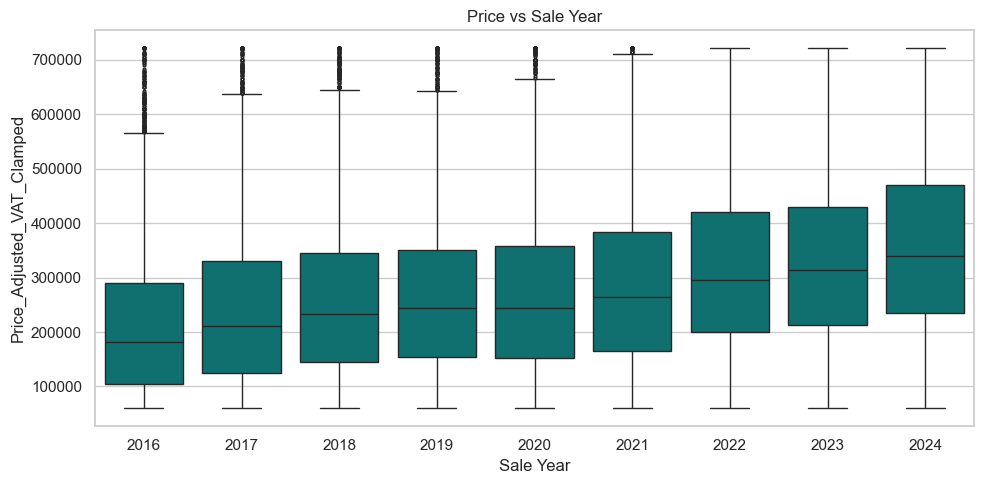

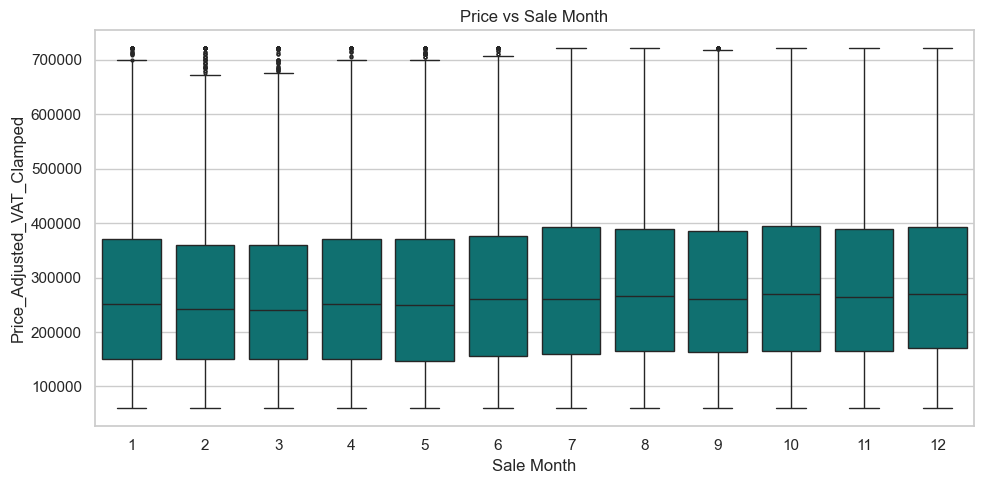

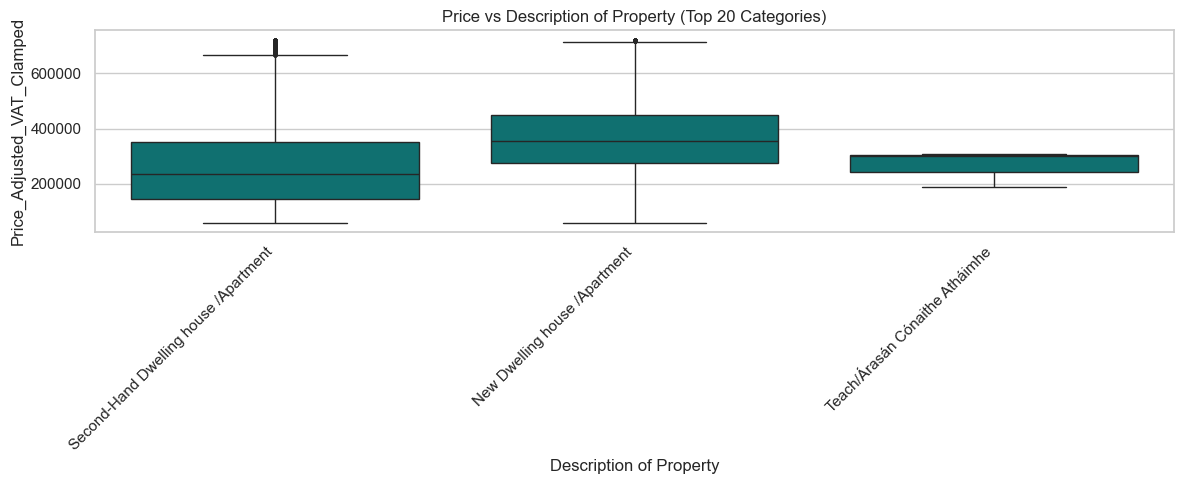

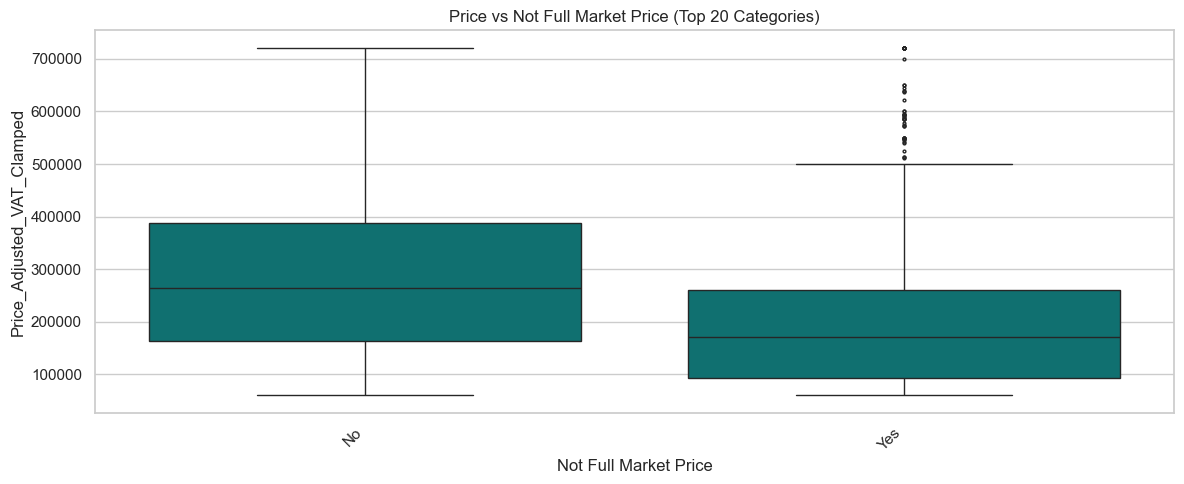

In [69]:
# Cell purpose: draw target-price boxplots (Price_Adjusted_VAT) for selected features and save figures.
import re
from pathlib import Path
MAX_CATS = 20
MIN_NON_NULL = 50
PLOT_DIR = Path('feature_pair_plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plot_log = []

def _safe_name(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_')

for feature in selected_features:
    tmp = work[[target, feature]].dropna().copy()

    if len(tmp) < MIN_NON_NULL:
        plot_log.append({'Feature': feature, 'Status': 'skip', 'Reason': f'too few rows ({len(tmp)})', 'File': ''})
        continue

    if feature in ['Sale Year', 'Sale Month']:
        tmp[feature] = pd.to_numeric(tmp[feature], errors='coerce').astype('Int64')
        tmp = tmp.dropna(subset=[feature]).copy()
        tmp[feature] = tmp[feature].astype(int).astype(str)

        order = sorted(tmp[feature].unique(), key=lambda x: int(x))
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=tmp, x=feature, y=target, order=order, color='teal', fliersize=2)
        plt.title(f'Price vs {feature}')
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.tight_layout()

        file_path = PLOT_DIR / f"boxplot_{_safe_name(feature)}_vs_{_safe_name(target)}.png"
        plt.savefig(file_path, dpi=180, bbox_inches='tight')
        plt.show()
        plt.close()

        plot_log.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'direct integer-group boxplot', 'File': str(file_path)})
        continue

    vc = tmp[feature].value_counts(dropna=True)
    top_levels = vc.head(MAX_CATS).index
    tmp2 = tmp[tmp[feature].isin(top_levels)].copy()

    if tmp2[feature].nunique(dropna=True) < 2:
        plot_log.append({'Feature': feature, 'Status': 'skip', 'Reason': 'categories < 2', 'File': ''})
        continue

    order = tmp2[feature].value_counts().index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=tmp2, x=feature, y=target, order=order, color='teal', fliersize=2)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Price vs {feature} (Top {MAX_CATS} Categories)')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.tight_layout()

    file_path = PLOT_DIR / f"boxplot_{_safe_name(feature)}_vs_{_safe_name(target)}.png"
    plt.savefig(file_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()

    plot_log.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'categorical boxplot', 'File': str(file_path)})



# 3) Correlation Analysis
After feature extraction, we use correlation views and boxplots to evaluate feature-price relationships.

Key observations:
- `County`: clear regional price differences; Dublin and Wicklow show higher price levels than many other counties.
- `Sale Year`: a positive year-to-price trend is visible, consistent with long-term market growth and inflation effects.
- `Sale Month`: month-level effect exists but is weaker than year-level effect; seasonal variation is present but limited.
- `Description of Property`: new dwelling records generally show higher price distribution than second-hand dwellings.
- `Not Full Market Price`: the `No` group has higher central tendency overall, while the `Yes` group shows more outliers.


# 4) New Feature Trials


Missing new features: ['dublin_district', 'dublin_district_missing', 'area_token', 'area_token_missing', 'eircode_missing', 'eircode_prefix']


,Feature,Type,NonNull,Unique
0,is_apartment,numeric,53991,2


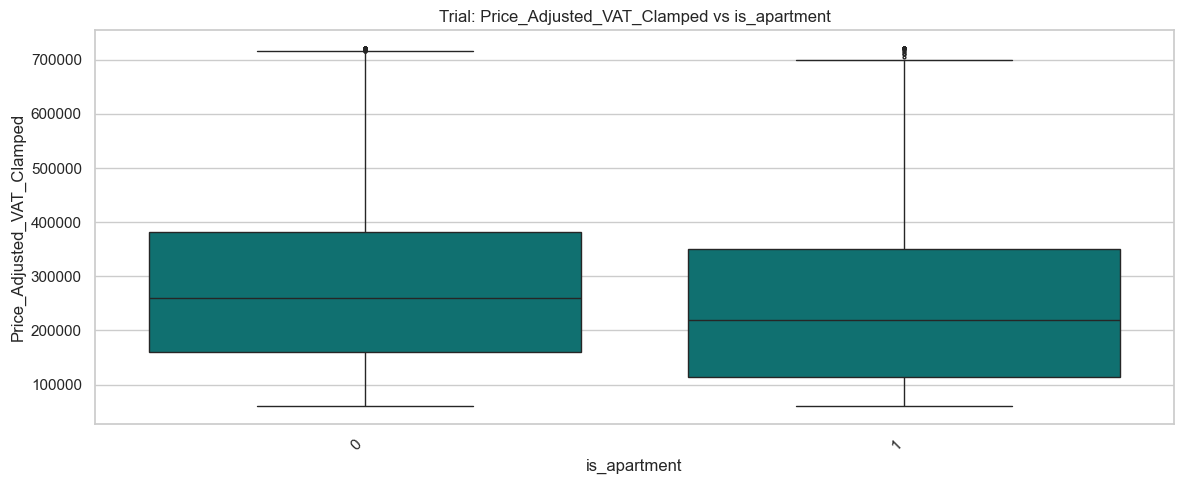

,Feature,Status,Reason,File
0,is_apartment,plotted,numeric low-cardinality grouped boxplot,feature_pair_plots_clean_trial_new_features/bo...


Saved images folder: feature_pair_plots_clean_trial_new_features


In [70]:
# Cell purpose: run trial feature-pair statistics and boxplots for new candidate features (without changing the confirmed 4-feature results).
import re
from pathlib import Path

csv_path = '../model_training/train_data_clean.csv'


df_trial = pd.read_csv(csv_path)

target_trial = 'Price_Adjusted_VAT_Clamped'
if target_trial not in df_trial.columns:
    raise KeyError("Column 'Price_Adjusted_VAT_Clamped' not found in dataset")

df_trial[target_trial] = pd.to_numeric(
    df_trial[target_trial].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

requested_new_features = [
    'is_apartment',
    'dublin_district',
    'dublin_district_missing',
    'area_token',
    'area_token_missing',
    'eircode_missing',
    'eircode_prefix',

]
requested_new_features = list(dict.fromkeys(requested_new_features))
selected_new_features = [c for c in requested_new_features if c in df_trial.columns and c != target_trial]
missing_new_features = [c for c in requested_new_features if c not in df_trial.columns]

if missing_new_features:
    print('Missing new features:', missing_new_features)
if target_trial in requested_new_features:
    print(f"Skip self-pair feature: {target_trial}")

work_trial = df_trial.dropna(subset=[target_trial]).copy()
for col in ['Sale Year', 'Sale Month']:
    if col in work_trial.columns:
        work_trial[col] = pd.to_numeric(work_trial[col], errors='coerce').astype('Int64').astype('category')

pair_rows_trial = []
for c in selected_new_features:
    s = work_trial[c]
    pair_rows_trial.append({
        'Feature': c,
        'Type': 'numeric' if pd.api.types.is_numeric_dtype(s) else 'categorical',
        'NonNull': int(s.notna().sum()),
        'Unique': int(s.nunique(dropna=True))
    })

pair_df_trial = pd.DataFrame(pair_rows_trial)
display(pair_df_trial)

PLOT_DIR_TRIAL = Path('feature_pair_plots_clean_trial_new_features')
PLOT_DIR_TRIAL.mkdir(parents=True, exist_ok=True)
MAX_CATS = 20
MIN_NON_NULL = 50
NUMERIC_UNIQUE_THRESHOLD = 20
NUMERIC_BINS = 10
plot_log_trial = []

def safe_name_trial(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_')

for feature in selected_new_features:
    tmp = work_trial[[target_trial, feature]].dropna().copy()

    if len(tmp) < MIN_NON_NULL:
        plot_log_trial.append({'Feature': feature, 'Status': 'skip', 'Reason': f'too few rows ({len(tmp)})', 'File': ''})
        continue

    feature_num = pd.to_numeric(tmp[feature], errors='coerce')
    is_numeric_feature = pd.api.types.is_numeric_dtype(work_trial[feature])

    if is_numeric_feature:
        tmp = tmp.assign(_feature_num=feature_num).dropna(subset=['_feature_num']).copy()
        n_unique = int(tmp['_feature_num'].nunique(dropna=True))

        if n_unique <= 1:
            plot_log_trial.append({'Feature': feature, 'Status': 'skip', 'Reason': 'numeric unique values < 2', 'File': ''})
            continue

        if n_unique <= NUMERIC_UNIQUE_THRESHOLD:
            tmp['_feature_plot'] = tmp['_feature_num'].round(6).astype(str)
            order = [str(v) for v in sorted(tmp['_feature_num'].unique())]
            reason = 'numeric low-cardinality grouped boxplot'
        else:
            q = min(NUMERIC_BINS, n_unique)
            tmp['_feature_plot'] = pd.qcut(tmp['_feature_num'], q=q, duplicates='drop').astype(str)
            order = tmp['_feature_plot'].value_counts().index
            reason = f'numeric qcut boxplot (q={q})'

        plt.figure(figsize=(12, 5))
        sns.boxplot(data=tmp, x='_feature_plot', y=target_trial, order=order, color='teal', fliersize=2)
        plt.xticks(rotation=45, ha='right')
        plt.title(f'Trial: {target_trial} vs {feature}')
        plt.xlabel(feature)
        plt.ylabel(target_trial)
        plt.tight_layout()

        file_path = PLOT_DIR_TRIAL / f"boxplot_trial_{safe_name_trial(feature)}_vs_{safe_name_trial(target_trial)}.png"
        plt.savefig(file_path, dpi=180, bbox_inches='tight')
        plt.show()
        plt.close()

        plot_log_trial.append({'Feature': feature, 'Status': 'plotted', 'Reason': reason, 'File': str(file_path)})
        continue

    top_levels = tmp[feature].value_counts(dropna=True).head(MAX_CATS).index
    tmp2 = tmp[tmp[feature].isin(top_levels)].copy()

    if tmp2[feature].nunique(dropna=True) < 2:
        plot_log_trial.append({'Feature': feature, 'Status': 'skip', 'Reason': 'categories < 2', 'File': ''})
        continue

    order = tmp2[feature].value_counts().index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=tmp2, x=feature, y=target_trial, order=order, color='teal', fliersize=2)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Trial: {target_trial} vs {feature} (Top {MAX_CATS} Categories)')
    plt.xlabel(feature)
    plt.ylabel(target_trial)
    plt.tight_layout()

    file_path = PLOT_DIR_TRIAL / f"boxplot_trial_{safe_name_trial(feature)}_vs_{safe_name_trial(target_trial)}.png"
    plt.savefig(file_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()

    plot_log_trial.append({'Feature': feature, 'Status': 'plotted', 'Reason': 'categorical boxplot', 'File': str(file_path)})

plot_log_df_trial = pd.DataFrame(plot_log_trial)
display(plot_log_df_trial)

print('Saved images folder:', PLOT_DIR_TRIAL)




# 5) Correlation Review for Candidate New Features

Candidate feature findings:
- `is_apartment`: apartment records tend to have lower price distribution than non-apartment records; feature retained.
- `dublin_district`: strong within-Dublin price heterogeneity; combined with `County` into `location` for a more useful geographic signal.
- `area_token`: contains useful locality signal but has very high cardinality; not retained for the current linear-oriented modeling pipeline.


# 6) New Feature Construction

## New Feature Used in This Section
- `location`: a combined location feature that incorporates both `County` and `dublin_district`, providing a more granular spatial signal.

## Detailed Explanation of `location`

### 1) Relation to `Address_to_GPS`
`Address_to_GPS` provides the geographic enrichment pipeline:
- address -> latitude/longitude (`step1_geocode.py`)
- latitude/longitude -> `dublin_district` (`step2_districts.py`)
- optional rematch for unresolved Dublin cases (`step4_rematch.py`)

The key downstream signal is `dublin_district`, which provides finer spatial structure within Dublin.

### 2) Relation to `model_training`
In `model_training` (see `README.md` and training notebooks), `location` is treated as a categorical feature and one-hot encoded.
This allows models to learn spatial price differences while keeping feature engineering practical.

### 3) Construction Logic
`location` is built using `County` and `dublin_district`:
- If `County == Dublin` and `dublin_district` is valid, use district-level label (e.g., `Dublin 4`, `Dublin 6W`).
- Otherwise, use county-level label (`County`).
- If county is missing after fallback rules, assign `Unknown`.

## Practical Advantages
- More informative spatial signal than using only `County`.
- Lower cardinality and better generalization than raw `Address`.
- Fully aligned with the feature interface in `model_training`.


Total rows: 53991
location non-null: 53991
location missing: 0
location cardinality (unique non-null): 51
Top 20 location frequency:


,count,pct_%
location,,
Cork,5973,11.0630
Kildare,2925,5.4176
Galway,2598,4.8119
Meath,2325,4.3063
Limerick,2063,3.8210
Dublin 26,2000,3.7043
Wicklow,1924,3.5636
Wexford,1883,3.4876
Tipperary,1538,2.8486


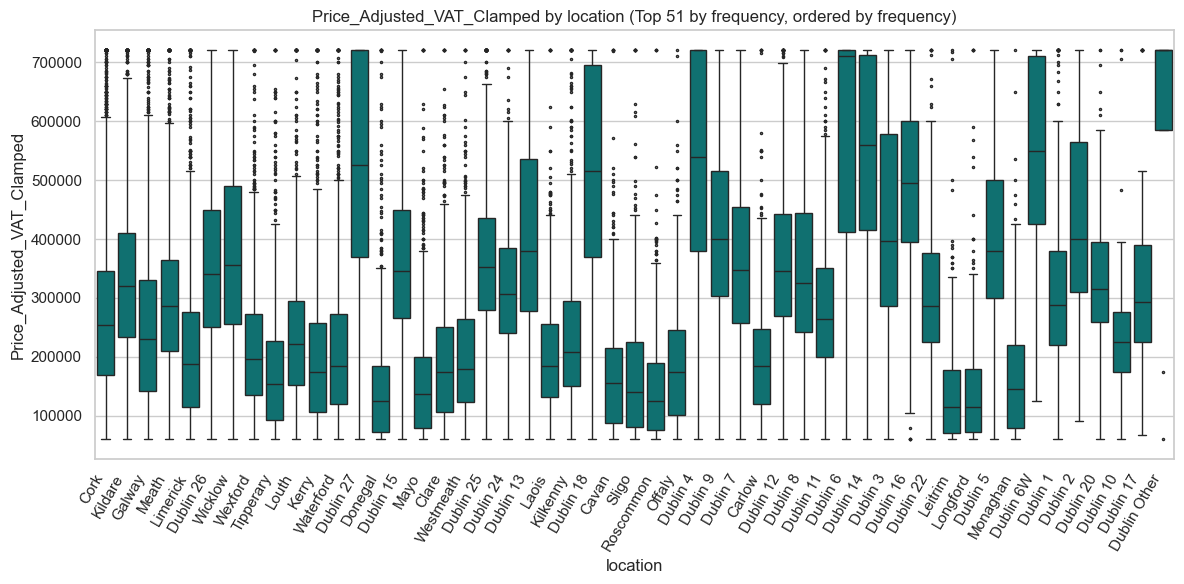

Rows plotted: 53991
Locations plotted: 51


In [73]:
# Cell purpose:
# 1) Use price from DQP clean-final dataset
# 2) Import `location` from model_training/train_data_clean.csv
# 3) Report location feature count and cardinality frequency
# 4) Plot a boxplot for location vs Price_Adjusted_VAT

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

price_path = '../model_training/train_data_clean.csv'
location_path = '../model_training/train_data_clean.csv'

df_preview = pd.read_csv(price_path)
df_loc = pd.read_csv(location_path, usecols=['location'])

if len(df_preview) != len(df_loc):
    raise ValueError(
        f"Row count mismatch: len(df_preview)={len(df_preview)} vs len(df_loc)={len(df_loc)}"
    )

# location source is fixed to model_training/train_data_clean.csv
df_preview['location'] = df_loc['location']
df_preview['location'] = df_preview['location'].fillna('Unknown').astype(str)

target_col = 'Price_Adjusted_VAT_Clamped'
if target_col not in df_preview.columns:
    raise KeyError(f"Column '{target_col}' not found in dataset")

df_preview[target_col] = pd.to_numeric(
    df_preview[target_col].astype(str).str.replace('€', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

# 2) Summarize location count and cardinality frequency
total_rows = len(df_preview)
non_null_location = int(df_preview['location'].notna().sum())
location_cardinality = int(df_preview['location'].nunique(dropna=True))
missing_location = int(df_preview['location'].isna().sum())

print(f'Total rows: {total_rows}')
print(f'location non-null: {non_null_location}')
print(f'location missing: {missing_location}')
print(f'location cardinality (unique non-null): {location_cardinality}')

location_freq = df_preview['location'].value_counts(dropna=False).to_frame('count')
location_freq['pct_%'] = (location_freq['count'] / total_rows * 100).round(4)
print('Top 20 location frequency:')
display(location_freq.head(20))

# 3) location vs target boxplot (frequency-filtered)
plot_df = df_preview[['location', target_col]].dropna(subset=[target_col]).copy()
plot_df['location'] = plot_df['location'].astype(str)

TOP_N = 51
top_locations = plot_df['location'].value_counts().head(TOP_N).index
plot_df = plot_df[plot_df['location'].isin(top_locations)].copy()

freq_order = plot_df['location'].value_counts().index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x='location',
    y=target_col,
    order=freq_order,
    color='teal',
    fliersize=1.5
)
plt.xticks(rotation=60, ha='right')
plt.title(f'{target_col} by location (Top {TOP_N} by frequency, ordered by frequency)')
plt.xlabel('location')
plt.ylabel(target_col)
plt.tight_layout()
plt.show()

print('Rows plotted:', len(plot_df))
print('Locations plotted:', plot_df['location'].nunique())



# Conclusion
- `location` is highly useful for price prediction because it captures finer geographic variation, especially within Dublin districts.
- The retained engineered features are `Sale Year`, `Sale Month`, `is_apartment`, and `location`.
- Other candidates were not retained due to weaker signal or higher modeling complexity.
